In [1]:
getwd()

[1] "d:/Data/杂/yin"

In [27]:
library(vegan)
library(ggplot2)
library(tidyverse)
#%% my theme
my_theme = theme(axis.title = element_text(size = 20),
axis.text = element_text(size = 10),  legend.key.size = unit(40, "pt"),
                  legend.text = element_text(color = "black", size = 20),
                  legend.background = element_rect(fill = "white", color = "white"),
                  legend.title = element_text(size = 20),
                  legend.key = element_rect(fill = "white"))

### gene table

In [ ]:
gene = read.csv("count_table.csv")
gene = gene[,-1]
gene = column_to_rownames(gene,var = "Gene.id")

In [ ]:
group = read.csv("group.csv")
head(group)

In [ ]:
gene = gene[,group$sample]
gene_t = as.matrix(t(gene))
gene_dist = as.matrix(vegdist(gene_t, method = "bray"))
gene_pcoa = cmdscale(gene_dist, k = 2, eig = T, add = T)
eig = gene_pcoa$eig
adonis = adonis2(gene_t ~ group$group)
adonis
anosim = anosim(gene_dist, group$group,permutations = 999)
anosim

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Model,2,0.09195262,0.2817644,2.942256,0.019
Residual,15,0.23439319,0.7182356,NA,NA
Total,17,0.32634581,1.0000000,NA,NA



Call:
anosim(x = gene_dist, grouping = groupadj$group, permutations = 999) 
Dissimilarity: user supplied square matrix 

ANOSIM statistic R: 0.1062 
      Significance: 0.08 

Permutation: free
Number of permutations: 999


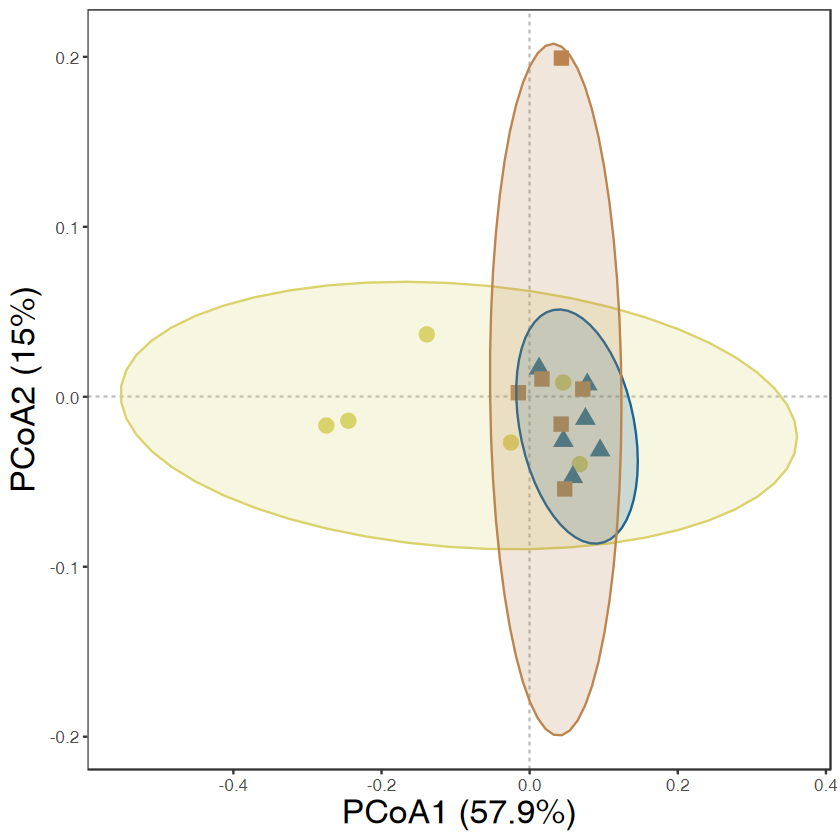

In [ ]:
gene_site = as.data.frame(gene_pcoa$points)
gene_site$group = group$group
colnames(gene_site) = c("PCoA1","PCoA2","group")

gene_site$group = factor(gene_site$group, levels = c("Severe","Middle","Mild"))
p1 = ggplot(gene_site, aes(PCoA1, PCoA2, color = group)) +
        geom_hline(yintercept = 0, linetype = "dashed", color = "grey") +
        geom_vline(xintercept = 0, linetype = "dashed", color = "grey") +
    geom_point(aes(shape = group), size = 4) +
    stat_ellipse(geom = "polygon", aes(fill = group), alpha = 0.2, show.legend = FALSE, level = 0.95) +
    labs(x = paste("PCoA1 (", format(100 * gene_pcoa$eig[1] / sum(gene_pcoa$eig), digits = 3), "%)", sep = ""),
         y = paste("PCoA2 (", format(100 * gene_pcoa$eig[2] / sum(gene_pcoa$eig), digits = 3), "%)", sep = "")) +
         theme_bw() +
         my_theme +
        scale_fill_manual(values = c("#DAD36D", "#1A6497", "#BC854F")) +
        scale_color_manual(values = c("#DAD36D", "#1A6497", "#BC854F")) +
        theme(panel.grid.major = element_blank(),
        panel.grid.minor = element_blank()) +
        theme(legend.position = "none")
p1
#ggsave("台式中的数据/尹老师/202408多组学/轴/gene/pcoa_gene.pdf", width = 6, height = 6)

#### metabolite

In [ ]:
met = read.csv("PLS-DA.sites.csv")
head(met)
colnames(met) = c("sample","PLS.DA1","PLS.DA2")

In [ ]:
met = left_join(met, group, by = "sample")
head(met)

,sample,PLS.DA1,PLS.DA2,group
,<chr>,<dbl>,<dbl>,<chr>
1,Middle3,8.085884,-2.1932757,Middle
2,Mild1,-4.685893,7.3992865,Middle
3,Mild3,4.097654,8.4837383,Middle
4,Mild5,2.067642,0.6969779,Middle
5,Severe1,7.530902,4.6682791,Middle
6,control6,-6.655315,15.2560043,Middle


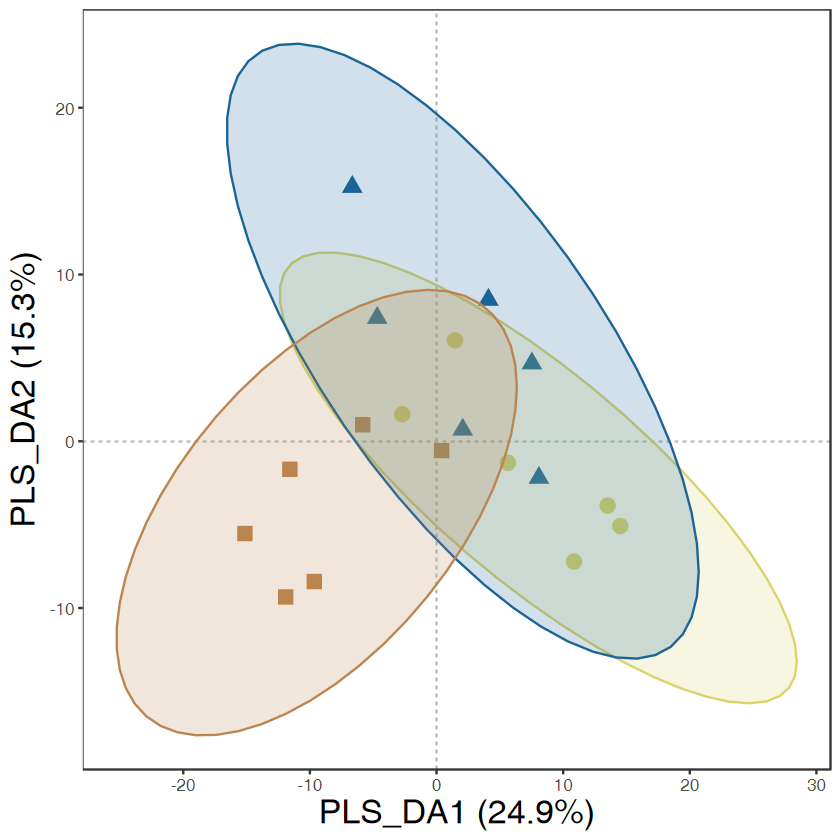

In [ ]:
met$group = factor(met$group, levels = c("Severe","Middle","Mild"))

p2 = ggplot(met, aes(PLS.DA1, PLS.DA2, color = group)) +
        geom_hline(yintercept = 0, linetype = "dashed", color = "grey") +
        geom_vline(xintercept = 0, linetype = "dashed", color = "grey") +
    geom_point(aes(shape = group), size = 4) +
    xlab("PLS_DA1 (24.9%)") +
    ylab("PLS_DA2 (15.3%)") +
    stat_ellipse(geom = "polygon", aes(fill = group), alpha = 0.2, show.legend = FALSE, level = 0.95)  +
         theme_bw() +
         my_theme +
        scale_fill_manual(values = c("#DAD36D", "#1A6497", "#BC854F")) +
        scale_color_manual(values = c("#DAD36D", "#1A6497", "#BC854F")) +
        theme(panel.grid.major = element_blank(),
        panel.grid.minor = element_blank()) +
        theme(legend.position = "none")
p2

### enrichment analysis

In [ ]:
library(clusterProfiler)
library(org.Mm.eg.db)

In [ ]:
se_en = read.csv("Severe_enrich.csv")
mid_en = read.csv("Middle_enrich.csv")
mil_en = read.csv("Mild_enrich.csv")

In [ ]:
se_en_ids = bitr(se_en$Gene.name, fromType = "SYMBOL", toType = c("ENTREZID"), OrgDb = org.Mm.eg.db)
mid_en_ids = bitr(mid_en$Gene.name, fromType = "SYMBOL", toType = c("ENTREZID"), OrgDb = org.Mm.eg.db)
mil_en_ids = bitr(mil_en$Gene.name, fromType = "SYMBOL", toType = c("ENTREZID"), OrgDb = org.Mm.eg.db)

In [96]:
se_id = unique(se_en_ids$ENTREZID)
mid_id = unique(mid_en_ids$ENTREZID)
mil_id = unique(mil_en_ids$ENTREZID)

In [ ]:
severe_kegg = enrichKEGG(gene = se_id, organism = "mmu", pvalueCutoff = 0.05, qvalueCutoff = 0.05,pAdjustMethod = "BH",
                        minGSSize = 10, maxGSSize = 500)

severe_kegg = setReadable(severe_kegg, OrgDb = org.Mm.eg.db, keyType = "ENTREZID")

severe_kegg =severe_kegg %>% as.data.frame() %>% mutate(sign = ifelse(p.adjust < 0.05, "yes", "no"),group = "Severe")


middle_kegg = enrichKEGG(gene = mid_id, organism = "mmu", pvalueCutoff = 0.05, qvalueCutoff = 0.05,pAdjustMethod = "BH",
                        minGSSize = 10, maxGSSize = 500)
middle_kegg = setReadable(middle_kegg, OrgDb = org.Mm.eg.db, keyType = "ENTREZID")
middle_kegg =middle_kegg %>% as.data.frame() %>% mutate(sign = ifelse(p.adjust < 0.05, "yes", "no"),group = "Middle")


mild_kegg = enrichKEGG(gene = mil_id, organism = "mmu", pvalueCutoff = 0.05, qvalueCutoff = 0.05,pAdjustMethod = "BH",
                        minGSSize = 10, maxGSSize = 500)
mild_kegg = setReadable(mild_kegg, OrgDb = org.Mm.eg.db, keyType = "ENTREZID")
mild_kegg =mild_kegg %>% as.data.frame() %>% mutate(sign = ifelse(p.adjust < 0.05, "yes", "no"),group = "Mild")

In [ ]:
pathway = rbind(severe_kegg, mid_kegg, mild_kegg)
write.csv(pathway, "pathway.csv", row.names = F)

#### significant metabolite and gene visualisation

In [ ]:
enrichmet = read.csv("metabolite_enrichment.csv")
enrichmet$group = factor(enrichmet$group, levels = c("Severe","Middle","Mild"))

enrichmet$Metabolite = factor(enrichmet$Metabolite, levels = c("Cystine-glutamate", "2-Decyl-3-Hydroxypentanedioic Acid","12-Hydroxydodecanoic acid","P-coumaroyltriacetic acid lactone","Dodecylbenzenesulfonic Acid",
"Etiracetam", "Xanthosine","Pelargonidin 3-sophoroside","Cimifugin"))
p3 = ggplot(enrichmet, aes(-log10(P_value), Metabolite)) +
    geom_bar(stat = "identity", aes(fill = group), position = "dodge") +
    theme_classic() +
    scale_x_continuous(expand = c(0, 0), limits = c(0, 7)) +
    theme(legend.position = "none") +
    my_theme +
            scale_fill_manual(values = c("#DAD36D", "#1A6497", "#BC854F")) +
        scale_color_manual(values = c("#DAD36D", "#1A6497", "#BC854F")) 

In [ ]:
df = read.csv("enrichment gene.csv")
head(df)

,Gene.id,Gene.name,Gene.description,FC,Pvalue,Padjust,Regulate,group
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,ENSMUSG00000000386,Mx1,MX dynamin-like GTPase 1 [Source:MGI Symbol;Acc:MGI:97243],15.815046,0.0000000598,0.00003060,up,Severe
2,ENSMUSG00000000409,Lck,lymphocyte protein tyrosine kinase [Source:MGI Symbol;Acc:MGI:96756],3.196121,0.0008831400,0.01860211,up,Severe
3,ENSMUSG00000000275,Trim25,tripartite motif-containing 25 [Source:MGI Symbol;Acc:MGI:102749],1.388608,0.0046170480,0.05019251,up,Severe
4,ENSMUSG00000000817,Fasl,"Fas ligand (TNF superfamily, member 6) [Source:MGI Symbol;Acc:MGI:99255]",2.656983,0.0076089240,0.06472807,up,Severe
5,ENSMUSG00000021277,Traf3,TNF receptor-associated factor 3 [Source:MGI Symbol;Acc:MGI:108041],1.445198,0.0249328970,0.21561378,up,Severe
6,ENSMUSG00000023274,Cd4,CD4 antigen [Source:MGI Symbol;Acc:MGI:88335],3.258331,0.0025467620,0.11052151,up,Middle


In [68]:
df$group = factor(df$group, levels = c("Severe","Middle","Mild"))
df$Gene.name = factor(df$Gene.name, levels = c("Ccnd1","Atp1a2","Chrm2","Adcy5","Mylk2","Ccl1","Il6","Rac3","Rac2","Cd4","Traf3","Fasl","Trim25","Lck","Mx1"))

p4 = ggplot(df, aes(-log10(Pvalue), Gene.name)) +
    geom_bar(stat = "identity", aes(fill = group), position = "dodge") +
    theme_classic() +
    scale_x_continuous(expand = c(0, 0), limits = c(0, 8)) +
    theme(legend.position = "none") +
    my_theme +
            scale_fill_manual(values = c("#DAD36D", "#1A6497", "#BC854F")) +
        scale_color_manual(values = c("#DAD36D", "#1A6497", "#BC854F")) +
        ylab("Gene name")

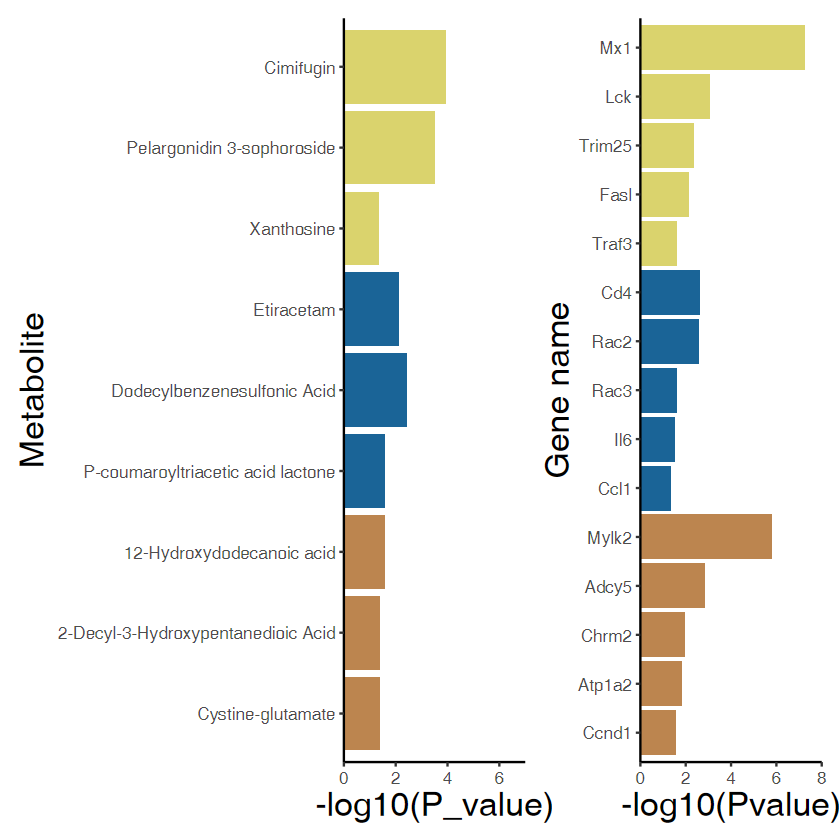

In [ ]:
library(patchwork)
p3 | p4

#### enrichment pathway

In [ ]:
path = read.csv("pathway.csv")
se_path = subset(path, group=="Severe")
mid_path = subset(path, group=="Middle")
mil_path = subset(path, group=="Mild")

In [70]:
colnames(path)

[1] "category"       "subcategory"    "ID"             "Description"   
 [5] "GeneRatio"      "BgRatio"        "RichFactor"     "FoldEnrichment"
 [9] "zScore"         "pvalue"         "p.adjust"       "qvalue"        
[13] "geneID"         "Count"          "sign"           "group"

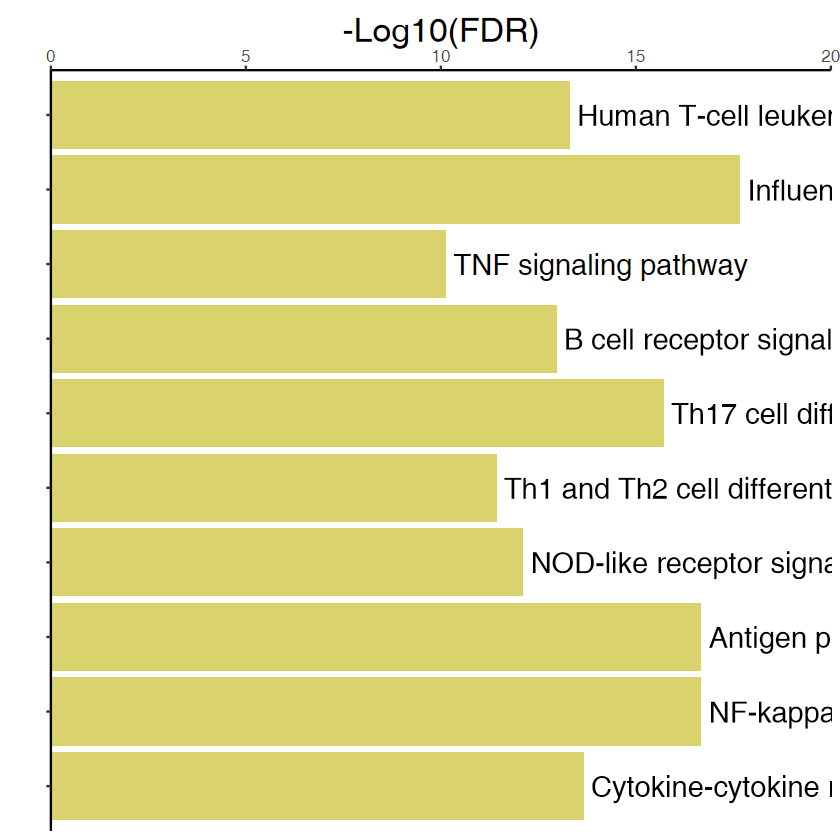

In [72]:
p_s = ggplot(se_path, aes(-log10(p.adjust), ID)) +
    geom_bar(stat = "identity",  position = "dodge", fill = "#DAD36D") +
    theme_classic() +
    scale_x_continuous(expand = c(0, 0), limits = c(0, 20),position = "top") +
    theme(legend.position = "none") +
    my_theme +
#   scale_fill_manual(values = c("#DAD36D", "#1A6497", "#BC854F")) +
#   scale_color_manual(values = c("#DAD36D", "#1A6497", "#BC854F")) +
        ylab("") +
        xlab("-Log10(FDR)") +
        geom_text(aes(label = Description), hjust = 0, size = 6, nudge_x = 0.2) +
        theme(axis.text.y = element_blank())
p_s

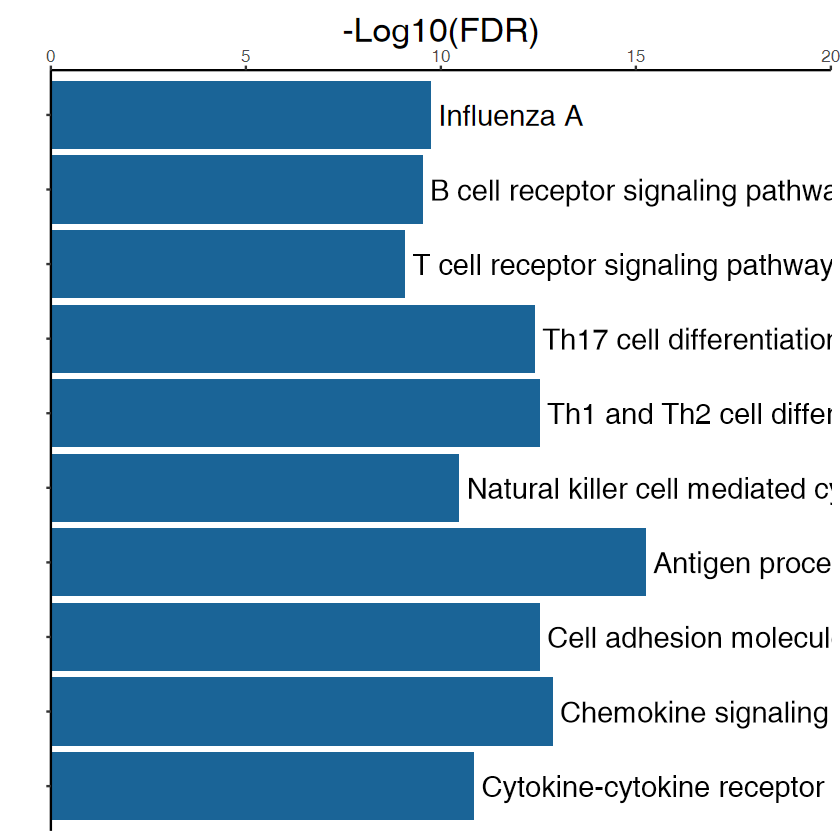

In [71]:
p_mid = ggplot(mid_path, aes(-log10(p.adjust), ID)) +
    geom_bar(stat = "identity",  position = "dodge", fill = "#1A6497") +
    theme_classic() +
    scale_x_continuous(expand = c(0, 0), limits = c(0, 20),position = "top") +
    theme(legend.position = "none") +
    my_theme +
#   scale_fill_manual(values = c("#DAD36D", "#1A6497", "#BC854F")) +
#   scale_color_manual(values = c("#DAD36D", "#1A6497", "#BC854F")) +
        ylab("") +
        xlab("-Log10(FDR)") +
        geom_text(aes(label = Description), hjust = 0, size = 6, nudge_x = 0.2) +
        theme(axis.text.y = element_blank())
p_mid

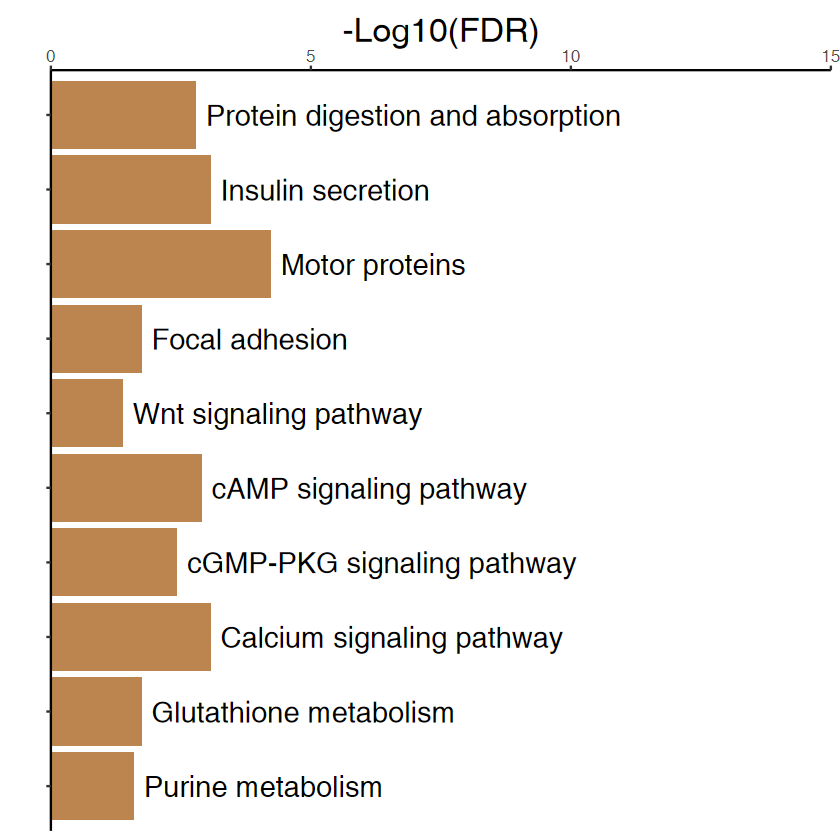

In [77]:
p_mil = ggplot(mil_path, aes(-log10(p.adjust), ID)) +
    geom_bar(stat = "identity",  position = "dodge", fill = "#BC854F") +
    theme_classic() +
    scale_x_continuous(expand = c(0, 0), limits = c(0, 15),position = "top") +
    theme(legend.position = "none") +
    my_theme +
#   scale_fill_manual(values = c("#DAD36D", "#1A6497", "#BC854F")) +
#   scale_color_manual(values = c("#DAD36D", "#1A6497", "#BC854F")) +
        ylab("") +
        xlab("-Log10(FDR)") +
        geom_text(aes(label = Description), hjust = 0, size = 6, nudge_x = 0.2) +
        theme(axis.text.y = element_blank())
p_mil

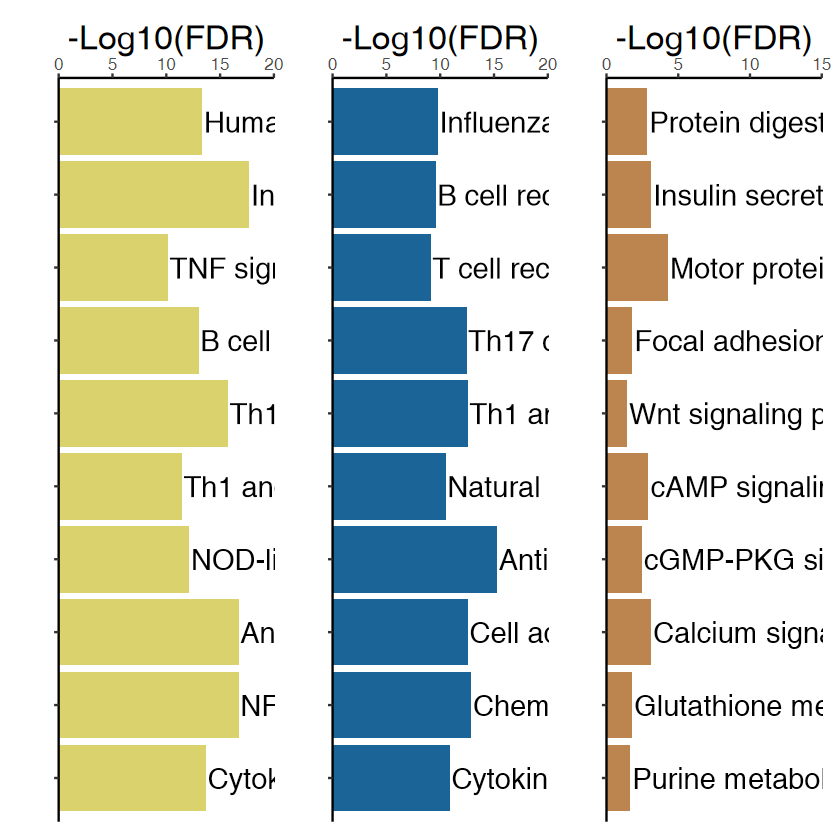

In [ ]:
p_s | p_mid | p_mil
ggsave("pathway.pdf", width = 12, height = 4)